In [8]:
import numpy as np
import sympy as sp
from array import array
from utils import *
from time import time

## Example 10

In [12]:
start = time()
T1 = sp.MutableDenseNDimArray([[[1,3],[2,4]],[[5,7],[6,8]]])
T2 = sp.MutableDenseNDimArray([[[9,11],[10,12]],[[13,15],[14,16]]])
T3 = sp.MutableDenseNDimArray([[[17,19],[18,20]],[[21,23],[22,24]]])

list(general_BM_product([T1,T2,T3]))
print(time()-start)

0.0018651485443115234


## Example 26a
### Markov Chain $(a,b,c)$

In [13]:
start = time()
a = sp.symbols("a")
b = sp.symbols("b")
T1o = sp.MutableDenseNDimArray([a,b])
T2o = sp.MutableDenseNDimArray([[a,b],[b,a]])
T3o = sp.MutableDenseNDimArray([[a,b],[b,a]])
T1 = forget(blow(T1o),2)
T2 = blow(T2o)
T3 = forget(T3o,0)
BPM = general_BM_product([T3,T1,T2])
print(time()-start)

0.0029137134552001953


## Example 26b
### Example 26a without link $b \rightarrow c$

In [14]:
start = time()
a = sp.symbols("a")
b = sp.symbols("b")
T1o = sp.MutableDenseNDimArray([a,b])
T2o = sp.MutableDenseNDimArray([[a,b],[b,a]])
T3o = T1o
T1 = forget(blow(T1o),2)
T2 = blow(T2o)
T3 = forget(forget(T3o,0),1)
BPM = general_BM_product([T3,T1,T2])
print(time()-start)

0.002583026885986328


## Example 27


In [20]:
start = time()
a = sp.symbols("a")
b = sp.symbols("b")
T = sp.MutableDenseNDimArray([a,b])
q = 3
T_list = []
for i in range(q):
    T_list.append(T)
    print(f'Node {i}')
    back_forget_list = [j for j in range(i)]
    forw_forget_list = [j for j in range(i+2,q)]
    print(f'J = {back_forget_list}, forward_forget_list={forw_forget_list}')
    for pos in back_forget_list:
        T_list[-1] = forget(T_list[-1],pos)
    if len(T_list[-1].shape)<q:
        T_list[-1] = blow(T_list[-1])
        print('Blow applied')
    else:
        print('Blow not applied')
    for pos in forw_forget_list:
        T_list[-1] = forget(T_list[-1],pos)
BPM = general_BM_product(T_list)
print(time()-start)

Node 0
J = [], forward_forget_list=[2]
Blow applied
Node 1
J = [0], forward_forget_list=[]
Blow applied
Node 2
J = [0, 1], forward_forget_list=[]
Blow not applied
0.01601099967956543


In [21]:
BPM

array([[[a**3, 0],
        [b**3, 0]],

       [[0, a**3],
        [0, b**3]]], dtype=object)

## Example 28
### Binary network with 5 nodes

In [30]:
start = time()
alpha = sp.symbols("alpha")
beta = sp.symbols("beta")
edge_index = np.array([[0,1],[0,2],[1,2],[1,4],[2,3],[3,4]])
q = 5  # Total number of nodes
adjacency_matrix_5 = edge_index_to_adj(edge_index, q)

A = sp.MutableDenseNDimArray([alpha,beta])
B = sp.MutableDenseNDimArray([[alpha,beta],[beta,alpha]])
D = B
C = sp.MutableDenseNDimArray([[[alpha,beta],[beta,alpha]],[[beta,alpha],[beta,alpha]]])
E = C

# A = forget(forget(forget(blow(A),2),3),4)
# B = forget(forget(blow(B),3),4)
# C = forget(blow(C),4)
# D = blow(forget(forget(D,0),1))
# E = forget(forget(E,0),2)

t_list_5 = [A,B,C,D,E]

t_list_expanded_5 = create_network(adjacency_matrix_5,t_list_5)

from time import time

bm_prod_5 = general_BM_product([t_list_expanded_5[-1]]+t_list_expanded_5[:4])
t_final = time()-start
print(f'Elapsed time: {t_final} seconds')


Elapsed time: 0.009840011596679688 seconds


In [31]:
bm_prod_5

array([[[[[alpha**5, alpha**4*beta],
          [alpha**3*beta**2, alpha**4*beta]],

         [[alpha**3*beta**2, alpha**2*beta**3],
          [alpha**3*beta**2, alpha**4*beta]]],


        [[[alpha**2*beta**3, alpha**3*beta**2],
          [alpha*beta**4, alpha**2*beta**3]],

         [[alpha**2*beta**3, alpha**3*beta**2],
          [alpha**3*beta**2, alpha**4*beta]]]],



       [[[[alpha**2*beta**3, alpha*beta**4],
          [beta**5, alpha*beta**4]],

         [[alpha**2*beta**3, alpha*beta**4],
          [alpha**2*beta**3, alpha**3*beta**2]]],


        [[[alpha**2*beta**3, alpha**3*beta**2],
          [alpha*beta**4, alpha**2*beta**3]],

         [[alpha**2*beta**3, alpha**3*beta**2],
          [alpha**3*beta**2, alpha**4*beta]]]]], dtype=object)

### Example with 7 nodes

In [32]:
start = time()
alpha = sp.symbols("alpha")
beta = sp.symbols("beta")

edge_index_7 = np.array([[0,1],[0,2],[1,2],[1,4],[2,3],[3,4],[4,5],[4,6],[5,6]])
q = 7  # Total number of nodes
adjacency_matrix_7 = edge_index_to_adj(edge_index_7, q)

A = sp.MutableDenseNDimArray([alpha,beta])
B = sp.MutableDenseNDimArray([[alpha,beta],[beta,alpha]])
D = B
C = sp.MutableDenseNDimArray([[[alpha,beta],[beta,alpha]],[[beta,alpha],[beta,alpha]]])
E = C
F = B
G = C

t_list_7 = [A,B,C,D,E,F,G]

# A = forget(forget(forget(forget(forget(blow(A),2),3),4),5),6)
# B = forget(forget(forget(forget(blow(B),3),4),5),6)
# C = forget(forget(forget(blow(C),4),5),6)
# D = forget(forget(blow(forget(forget(D,0),1)),5),6)

# E = forget(blow(forget(forget(E,0),2)),6)
# F = blow(forget(forget(forget(forget(F,0),1),2),3))
# G = forget(forget(forget(forget(G,0),1),2),3)

t_list_expanded_7 = create_network(adjacency_matrix_7, t_list_7)
from time import time
t0 = time()
bm_prod_7 = general_BM_product([t_list_expanded_7[-1]]+t_list_expanded_7[0:6])
t_final = time()-start
print(f'Elapsed time: {t_final} seconds')


Elapsed time: 0.04984712600708008 seconds


### Example with N nodes
We can generate a random list of tensors, with appropriate dimension w.r.t the topology of the given adjacency matrix, and then generate the network for which we can compute the BM product.

In [34]:
import numpy as np

def generate_source_sink_dag(num_nodes, p = 0.3):
    if num_nodes < 2:
        raise ValueError("Need at least 2 nodes for a source and a sink.")
        
    matrix = np.zeros((num_nodes, num_nodes), dtype=int)
    
    # 1. Create a "backbone" to guarantee connectivity from Source to Sink
    # This ensures node 0 -> 1 -> 2 ... -> (n-1)
    for i in range(num_nodes - 1):
        matrix[i][i+1] = 1
        
    # 2. Add random forward edges to make it interesting
    # We still only populate the upper triangle (j > i) to prevent cycles
    for i in range(num_nodes):
        for j in range(i + 2, num_nodes): # i+2 to avoid overwriting the backbone
            if np.random.rand() < p:
                matrix[i][j] = 1
                
    return matrix

Elapsed time for a network with 10 nodes: 0.16353702545166016 seconds
Elapsed time for a network with 11 nodes: 0.35141491889953613 seconds
Elapsed time for a network with 12 nodes: 0.7784850597381592 seconds
Elapsed time for a network with 13 nodes: 1.7292039394378662 seconds
Elapsed time for a network with 14 nodes: 3.8331449031829834 seconds
Elapsed time for a network with 15 nodes: 8.171488046646118 seconds
Elapsed time for a network with 16 nodes: 17.955014944076538 seconds
Elapsed time for a network with 17 nodes: 39.30682110786438 seconds
Elapsed time for a network with 18 nodes: 85.25075697898865 seconds
Elapsed time for a network with 19 nodes: 183.9531466960907 seconds


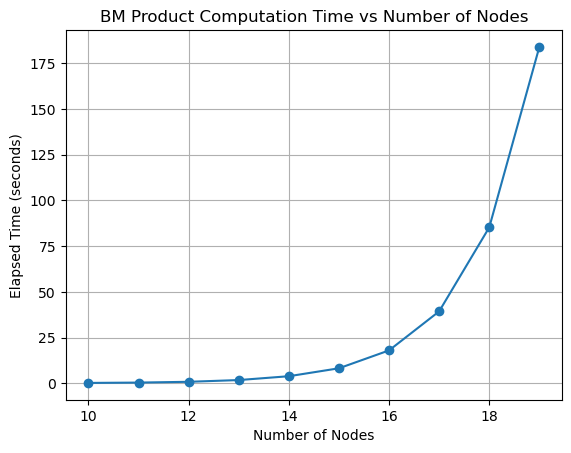

In [35]:
times = []
for nodes in range(10, 20):
    dag_matrix = generate_source_sink_dag(nodes)
    t_list_dag = create_network(dag_matrix, create_random_tensors(dag_matrix))
    
    t0 = time()
    bm_prod = BM_product([t_list_dag[-1]] + t_list_dag[:nodes-1])
    t_final = time()-t0
    times.append(t_final)
    print(f'Elapsed time for a network with {nodes} nodes: {t_final} seconds')
    
ax, fig = plt.subplots()
fig.plot(range(10, 20), times, marker='o')
fig.set_xlabel('Number of Nodes')
fig.set_ylabel('Elapsed Time (seconds)')
fig.set_title('BM Product Computation Time vs Number of Nodes')
plt.grid()
plt.show()